# Heuristics Benchmark 

This notebook can be used to plot the results of `benchmark_heuristics.py`.

In [46]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Results are written by benchmark_heuristics.py into scripts/benchmark/heuristics_benchmark/
NOTEBOOK_DIR = Path('.').resolve()
BASE_DIR = os.path.normpath(os.path.join(NOTEBOOK_DIR, '..', 'scripts', 'benchmark', 'heuristics_benchmark'))

# Collect data
records = []
if os.path.isdir(BASE_DIR):
    for method in sorted(os.listdir(BASE_DIR)):
        method_path = os.path.join(BASE_DIR, method)
        if not os.path.isdir(method_path):
            continue
        for bin_name in sorted(os.listdir(method_path)):
            solved_path = os.path.join(method_path, bin_name, 'solved.smi')
            if os.path.isfile(solved_path):
                with open(solved_path) as f:
                    count = sum(1 for line in f if line.strip())
                records.append({'method': method, 'bin': bin_name, 'solved': count})

if not records:
    print(f"No results found in {BASE_DIR}")
    print("Run scripts/benchmark/benchmark_heuristics.py first.")
    df = pd.DataFrame(columns=['method', 'bin', 'solved'])
else:
    df = pd.DataFrame(records)
    print(df.pivot(index='bin', columns='method', values='solved').to_string())

method   WxWxSAS  heavyAtomCount  heavyatomsXsascore  heavyatomsXscscore  sascore  sascoreXscscore  scscore  syba  weight  weightXsascore
bin                                                                                                                                      
1.5_2.5       81              86                  81                   0       84                0       84     0      86              81
2.5_3.5       44              67                  44                   0       55                0       58     0      63              45
3.5_4.5       17              34                  16                   0       30                0       30     0      37              17
4.5_5.5        2              10                   2                   0        3                0        5     0       9               2
5.5_6.5        6              10                   6                   0        8                0        0     0       9               6
6.5_7.5        0               0  

In [47]:
# Add Baseline overlay (optional)

baseline_method = "baseline"

baseline_bins = ["1.5_2.5", "2.5_3.5", "3.5_4.5", "4.5_5.5", "5.5_6.5", "6.5_7.5", "7.5_8.5"]
baseline_counts = [82, 51, 21, 4, 7, 0, 1]

for b, c in zip(baseline_bins, baseline_counts):
    records.append({'method': baseline_method, 'bin': b, 'solved': c})
df = pd.DataFrame(records)

In [48]:
# ── Configuration ─────────────────────────────────────────────────────────────

# Rename heuristic folder names for display.
# Keys are folder names; values are the labels shown on the legend.
# Methods NOT listed here are still plotted, using their folder name as label.
LABELS = {
    'baseline':         'Baseline',
    'sascore':          'SAScore',
    'scscore':          'SCScore',
    'syba':             'SYBA',
    'weight':           'Molecular Weight (MW)',
    'heavyAtomCount':   'Heavy Atoms (HA)',
    'heavyatomsXsascore': 'HA × SAScore',
    'heavyatomsXscscore': 'HA × SCScore',
    'sascoreXscscore':  'SAScore × SCScore',
    'weightXsascore':   'MW × SAScore',
    'WxWxSAS':          'MW² × SAScore',
}

# Ordered list of folder names to plot
ORDER = [
    'baseline',
    'sascore',
    'scscore',
    'syba',
    'weight',
    'heavyAtomCount',
    'heavyatomsXsascore',
    'heavyatomsXscscore',
    'sascoreXscscore',
    'weightXsascore',
    'WxWxSAS',
]

COLORS = {
    'baseline':         '#95a5a6',
    'sascore':          '#1f77b4',
    'scscore':          '#ff7f0e',
    'syba':             '#2ca02c',
    'weight':           '#d62728',
    'heavyAtomCount':   '#9467bd',
    'heavyatomsXsascore': '#8c564b',
    'heavyatomsXscscore': '#e377c2',
    'sascoreXscscore':  '#7f7f7f',
    'weightXsascore':   '#bcbd22',
    'WxWxSAS':          '#17becf',
}
# ──────────────────────────────────────────────────────────────────────────────

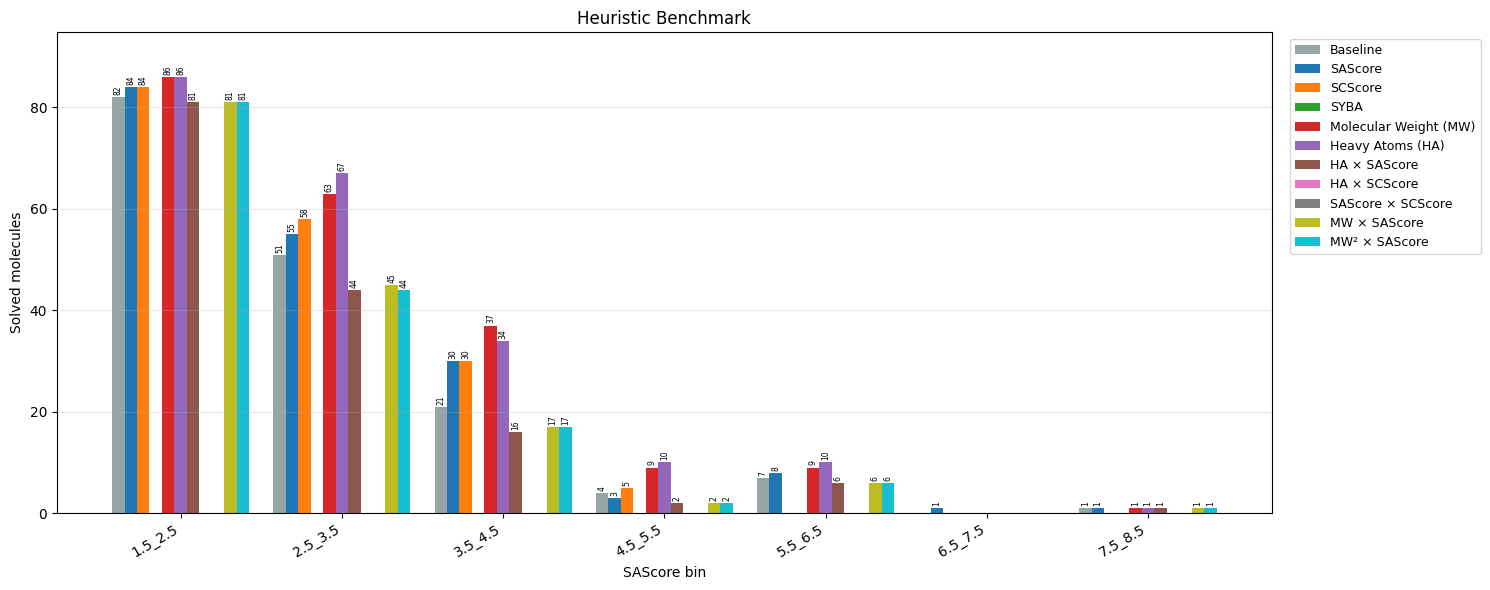

In [51]:
if df.empty:
    print("No data to plot. Run benchmark_heuristics.py first.")
else:
    all_methods = df['method'].unique().tolist()
    # Build final ordered list: explicit ORDER first, then remaining alphabetically
    ordered = [m for m in ORDER if m in all_methods]
    ordered += sorted(m for m in all_methods if m not in ordered)

    bins = sorted(df['bin'].unique(), key=lambda x: float(x.split('_')[0]))
    n_methods = len(ordered)
    x = np.arange(len(bins))
    width = 0.85 / n_methods

    # Auto-color fallback for methods not in COLORS
    auto_colors = plt.get_cmap('tab10').colors
    auto_idx = 0
    resolved_colors = {}
    for m in ordered:
        if m in COLORS:
            resolved_colors[m] = COLORS[m]
        else:
            resolved_colors[m] = auto_colors[auto_idx % len(auto_colors)]
            auto_idx += 1

    fig, ax = plt.subplots(figsize=(15, 6))

    for i, method in enumerate(ordered):
        subset = df[df['method'] == method].set_index('bin').reindex(bins)['solved'].fillna(0)
        offset = (i - n_methods / 2 + 0.5) * width
        bars = ax.bar(
            x + offset, subset.values,
            width=width,
            label=LABELS.get(method, method),
            color=resolved_colors[method],
        )
        # Label on top of each bar
        for bar, val in zip(bars, subset.values):
            if val > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.4,
                    str(int(val)),
                    ha='center', va='bottom',
                    fontsize=5.5, rotation=90,
                )

    ax.set_xticks(x)
    ax.set_xticklabels(bins, rotation=30, ha='right')
    ax.set_xlabel('SAScore bin')
    ax.set_ylabel('Solved molecules')
    ax.set_title('Heuristic Benchmark')
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    # Extra top margin so rotated labels don't clip
    ax.set_ylim(top=ax.get_ylim()[1] * 1.05)
    fig.tight_layout()
    plt.savefig('benchmark_heuristics_results.png', dpi=150)
    plt.show()